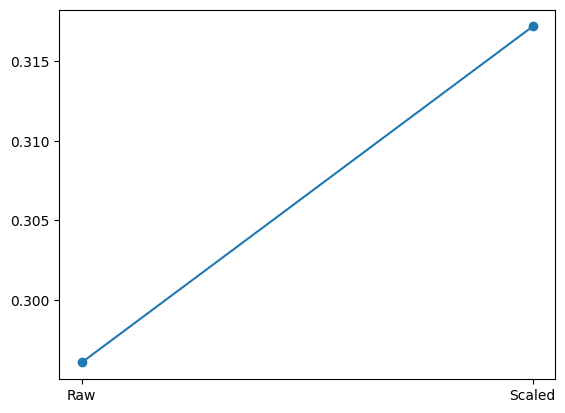

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

DATA_PATH = "/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv"

df = pd.read_csv(DATA_PATH)
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

target_col = "Sales" if "Sales" in df.columns else df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

results = []

model = RandomForestRegressor()
model.fit(X_train, y_train)
results.append(["Raw", *evaluate(y_test, model.predict(X_test))])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_scaled, y, test_size=0.2)

model.fit(Xs_train, ys_train)
results.append(["Scaled", *evaluate(ys_test, model.predict(Xs_test))])

df_results = pd.DataFrame(results, columns=["Setup","MAE","RMSE","R2"])
df_results.to_csv("RQ5_table.csv", index=False)

plt.figure()
plt.plot(df_results["Setup"], df_results["R2"], marker='o')
plt.savefig("RQ5_figure.pdf")
plt.show()
